In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
from sklearn import linear_model,metrics,preprocessing

In [16]:
train=np.loadtxt("q5_train.csv",skiprows=1,delimiter=",")
test=np.loadtxt("q5_test.csv",skiprows=1,delimiter=",")
X_train, y_train = train[:, :-1], train[:, -1]
X_test = test[:, :]

In [17]:
std=preprocessing.RobustScaler()
std.fit(X_train)
std_X_train=std.transform(X_train)
std_X_test=std.transform(X_test)

x = std_X_train[:, 7]
median = np.median(x)
mad = np.median(np.abs(x - median))
mask = np.abs(x - median) <= 3 * mad

X_train_clean = std_X_train[mask]
y_train_clean = y_train[mask]
train_clean = train[mask]

print(X_train_clean.shape, X_train.shape)

(222, 8) (240, 8)


# Corr Coeff

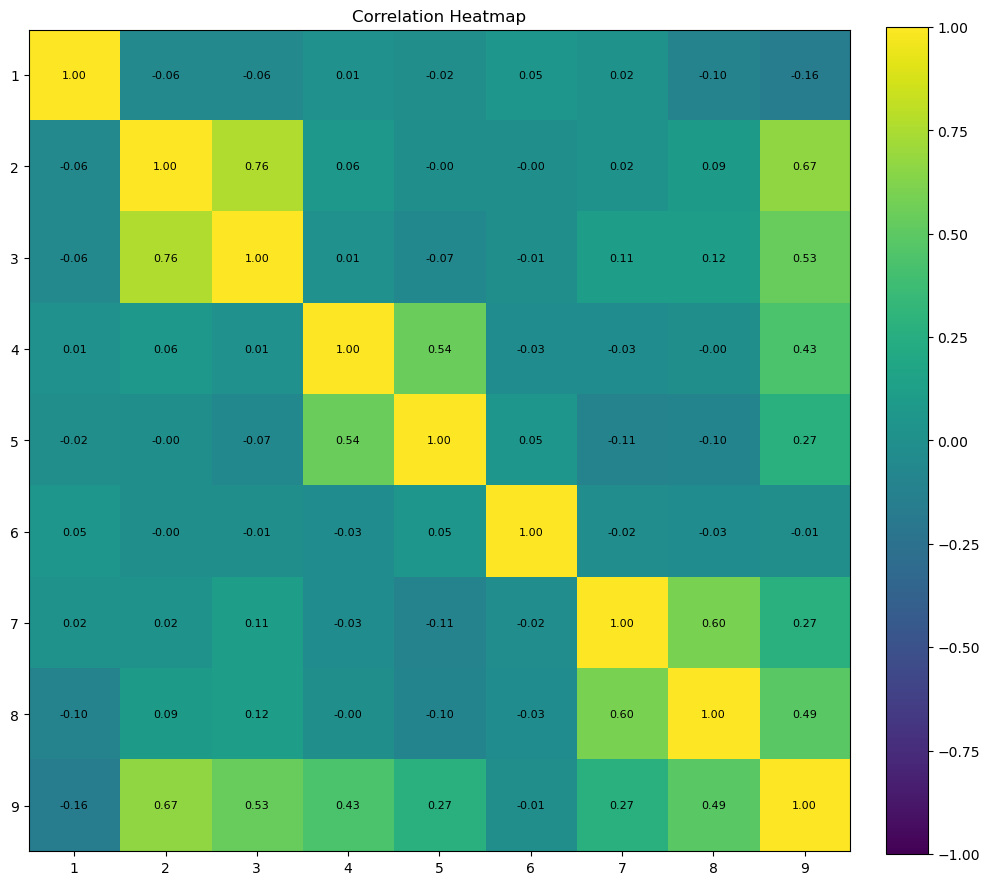

In [18]:
corr = np.corrcoef(train_clean, rowvar=False)

n = corr.shape[0]
labels = np.arange(1, n + 1)

plt.figure(figsize=(10, 10))
im = plt.imshow(corr, vmin=-1, vmax=1)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(n), labels)
plt.yticks(np.arange(n), labels)

# annotate values
for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatter plot

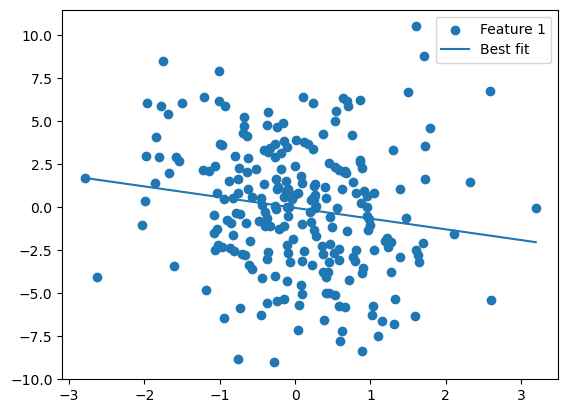

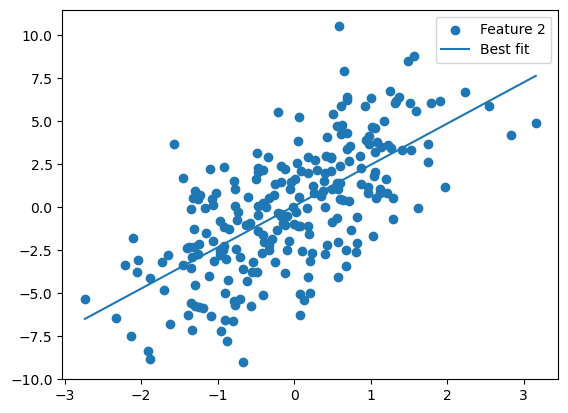

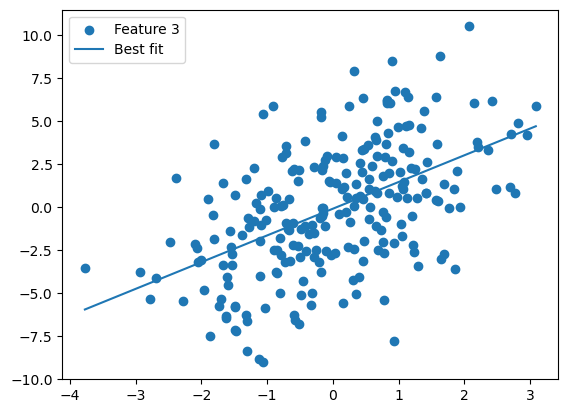

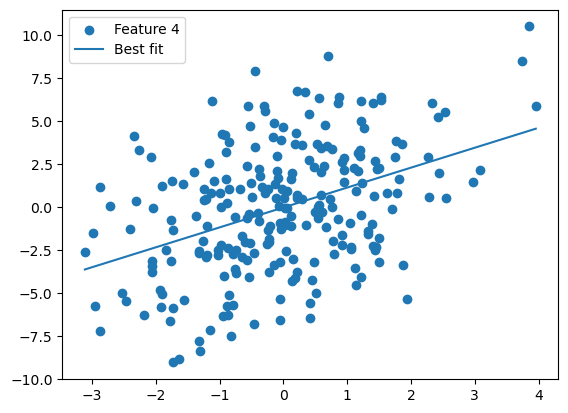

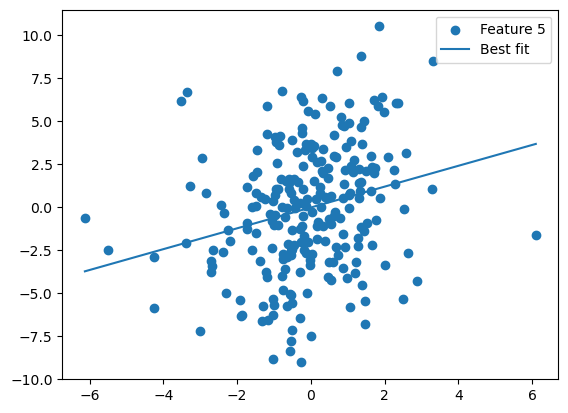

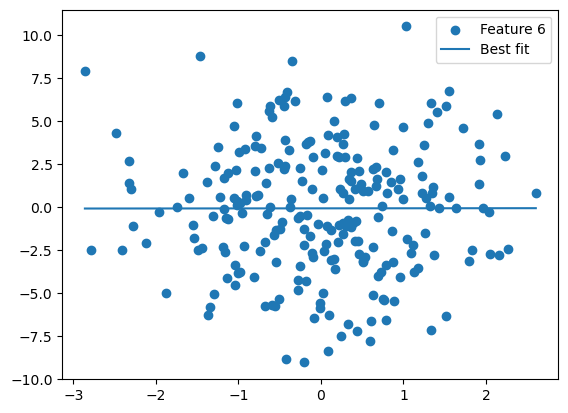

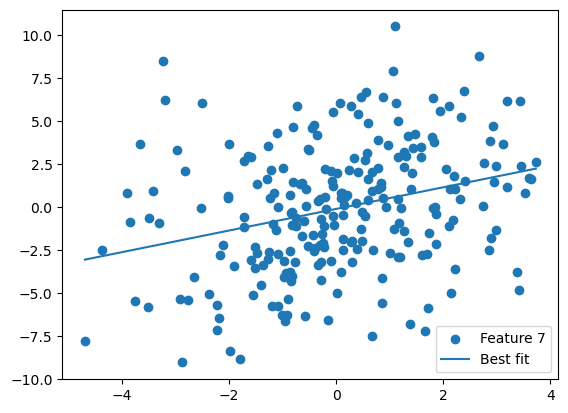

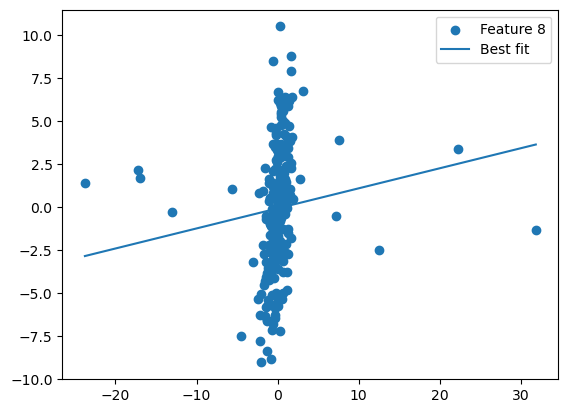

In [19]:
for i in range(X_train.shape[1]):
    x = X_train[:, i]
    plt.figure()
    plt.scatter(x, y_train, label=f'Feature {i+1}')
    plt.plot(np.sort(x), np.polyval(np.polyfit(x, y_train, 1), np.sort(x)), label='Best fit')
    plt.legend()
    plt.show()

# Ridge and Lasso

[-0.58666043  2.20585518  0.07311211  0.92317255  0.2841504   0.0256194
  0.65040532  0.06284771]
8


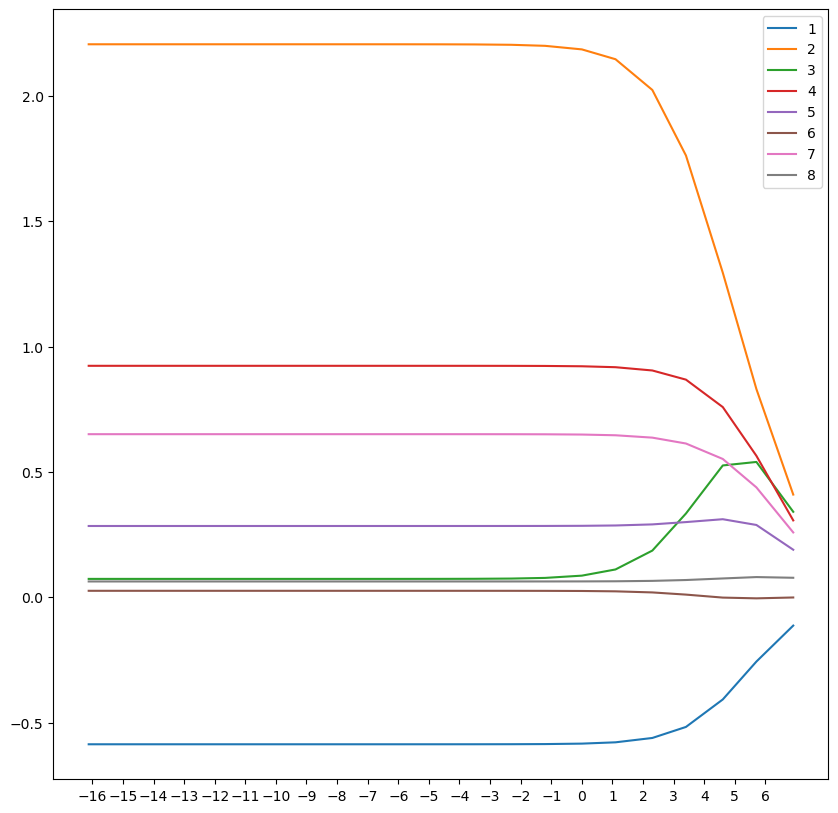

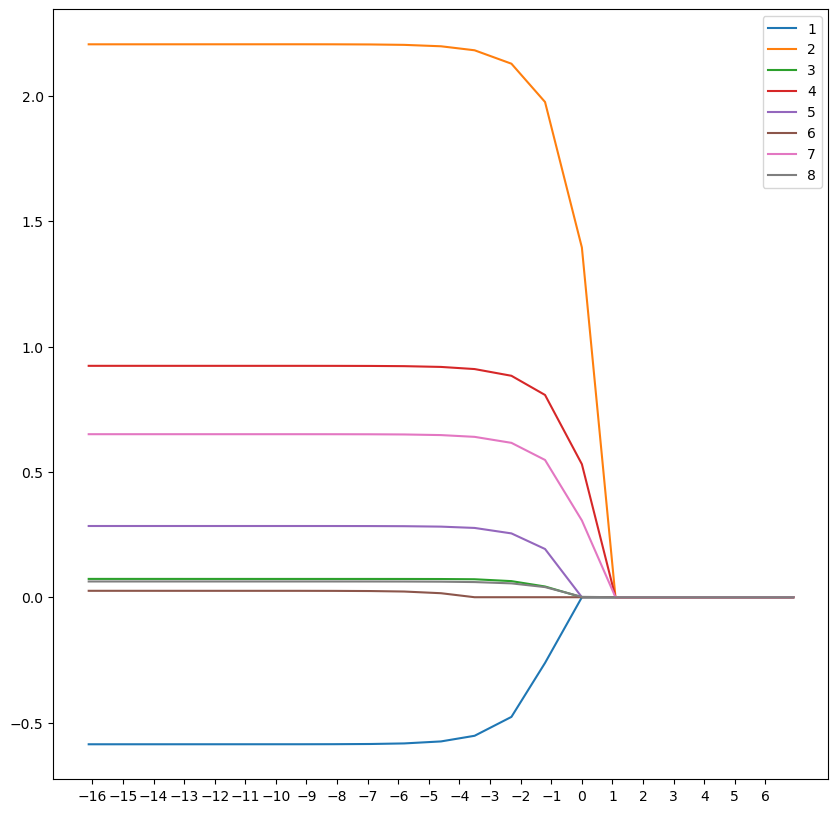

In [20]:
alphas = [1e-7, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1, 3, 10, 30, 100, 300, 1000]
log_al=np.log(np.array(alphas))
reg=linear_model.LinearRegression()
reg.fit(X_train,y_train)
print(reg.coef_)

features=reg.coef_.size
print(features)
coeffs=[]
for i in alphas:
    ridge=linear_model.Ridge(alpha=i)
    ridge.fit(X_train,y_train)
    coeffs.append(ridge.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.xticks(np.arange(int(log_al.min()), int(log_al.max()) + 1))
plt.legend()
plt.show()

coeffs=[]
for i in alphas:
    lasso=linear_model.Lasso(alpha=i)
    lasso.fit(X_train,y_train)
    coeffs.append(lasso.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.xticks(np.arange(int(log_al.min()), int(log_al.max()) + 1))
plt.legend()
plt.show()


# Ridge and Lasso for Standardised

[-0.75628447  3.38927065  0.12550369  1.63148444  0.52543588  0.03542887
  1.44837967  0.08827866]
8


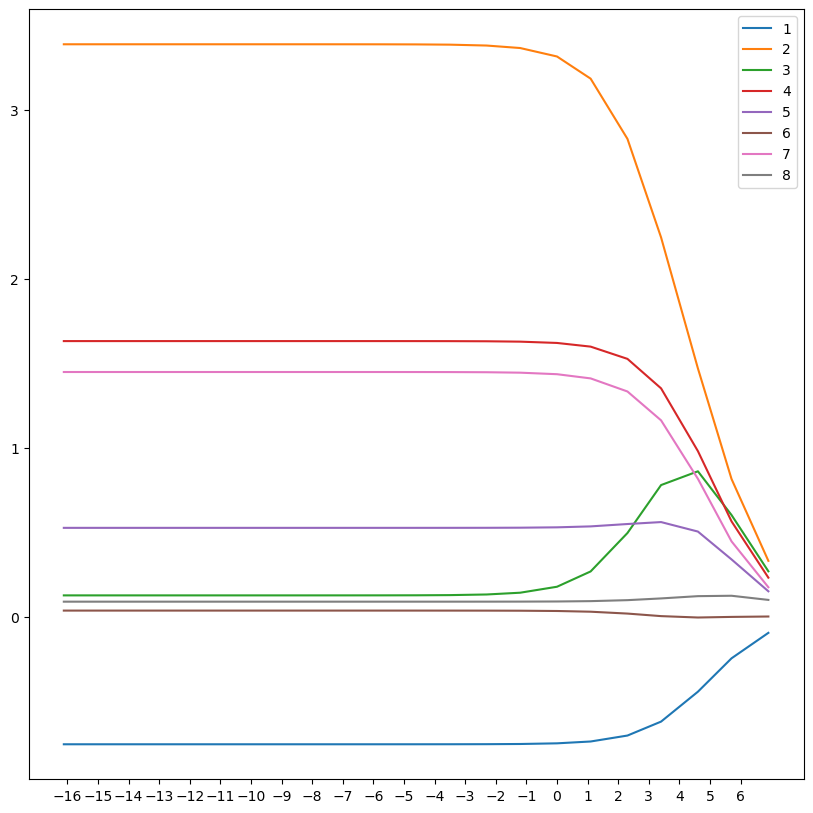

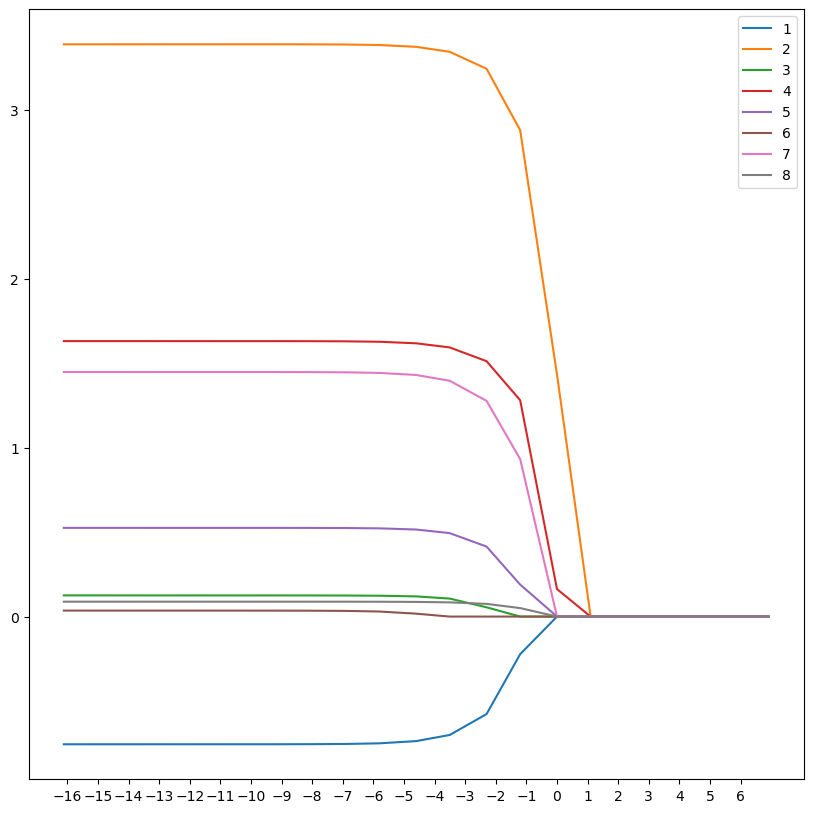

In [21]:
alphas = [1e-7, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1, 3, 10, 30, 100, 300, 1000]
log_al=np.log(np.array(alphas))
reg=linear_model.LinearRegression()
reg.fit(std_X_train,y_train)
print(reg.coef_)

features=reg.coef_.size
print(features)
coeffs=[]
for i in alphas:
    ridge=linear_model.Ridge(alpha=i)
    ridge.fit(std_X_train,y_train)
    coeffs.append(ridge.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.xticks(np.arange(int(log_al.min()), int(log_al.max()) + 1))
plt.legend()
plt.show()

coeffs=[]
for i in alphas:
    lasso=linear_model.Lasso(alpha=i)
    lasso.fit(std_X_train,y_train)
    coeffs.append(lasso.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.xticks(np.arange(int(log_al.min()), int(log_al.max()) + 1))
plt.legend()
plt.show()


# Outliers Removed

[-0.41823407  3.14183177  0.22711295  1.58548327  0.62789083  0.04975369
  0.09436434  2.52935877]
8


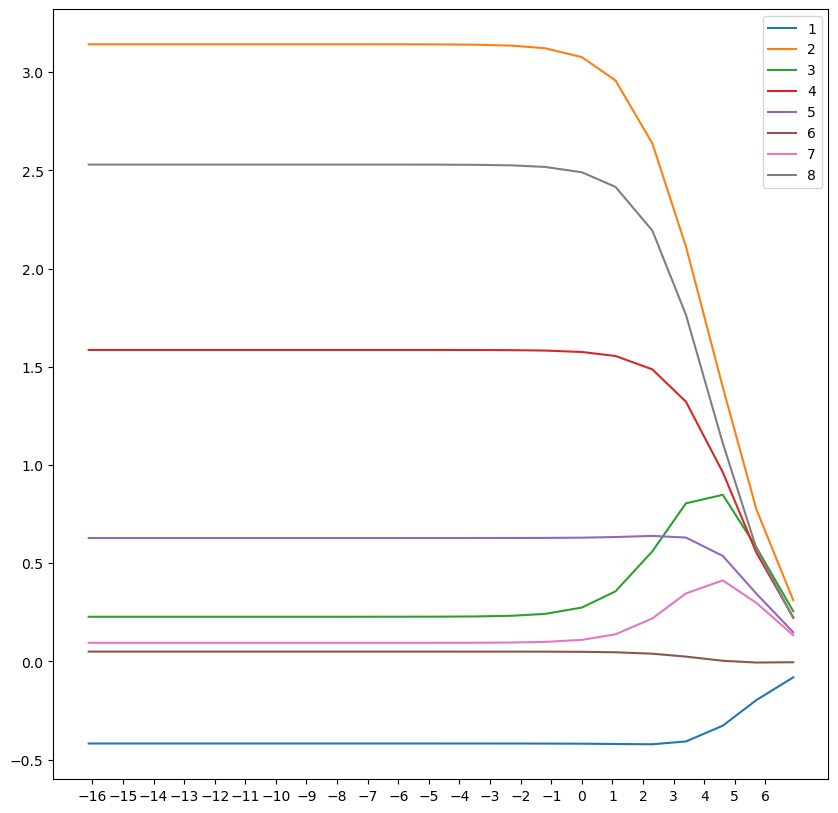

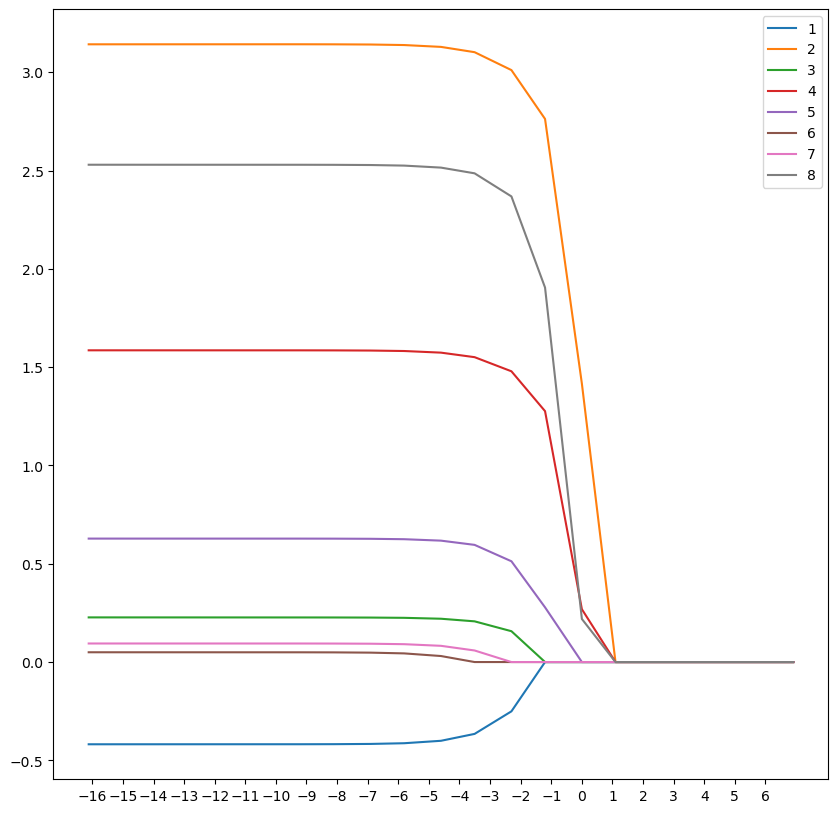

In [22]:
alphas = [1e-7, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1, 3, 10, 30, 100, 300, 1000]
log_al=np.log(np.array(alphas))
reg=linear_model.LinearRegression()
reg.fit(X_train_clean,y_train_clean)
print(reg.coef_)

features=reg.coef_.size
print(features)
coeffs=[]
for i in alphas:
    ridge=linear_model.Ridge(alpha=i)
    ridge.fit(X_train_clean,y_train_clean)
    coeffs.append(ridge.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.xticks(np.arange(int(log_al.min()), int(log_al.max()) + 1))
plt.legend()
plt.show()

coeffs=[]
for i in alphas:
    lasso=linear_model.Lasso(alpha=i)
    lasso.fit(X_train_clean,y_train_clean)
    coeffs.append(lasso.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.xticks(np.arange(int(log_al.min()), int(log_al.max()) + 1))
plt.legend()
plt.show()


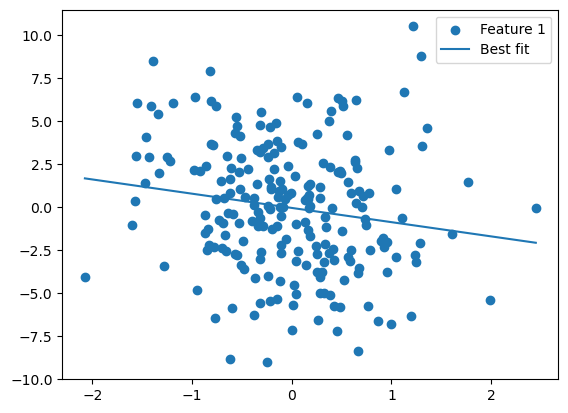

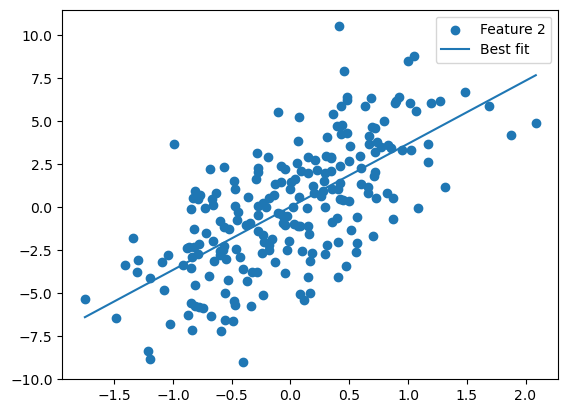

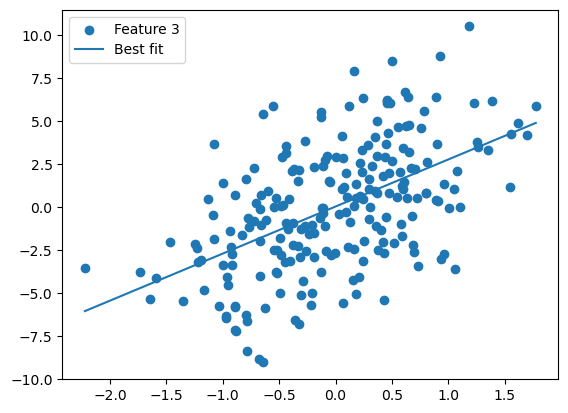

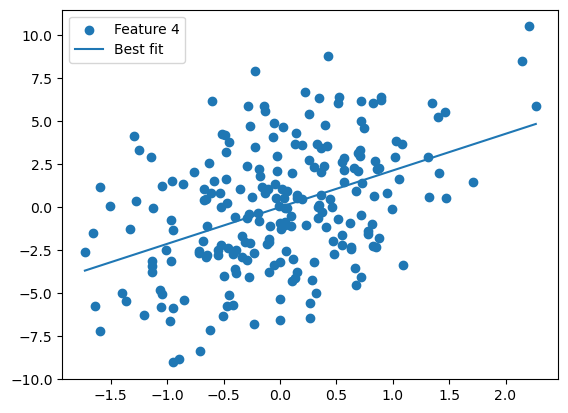

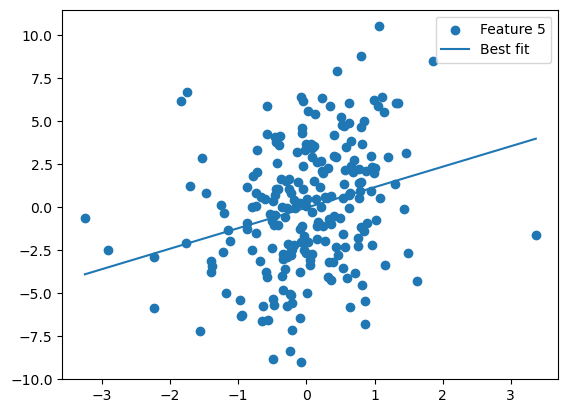

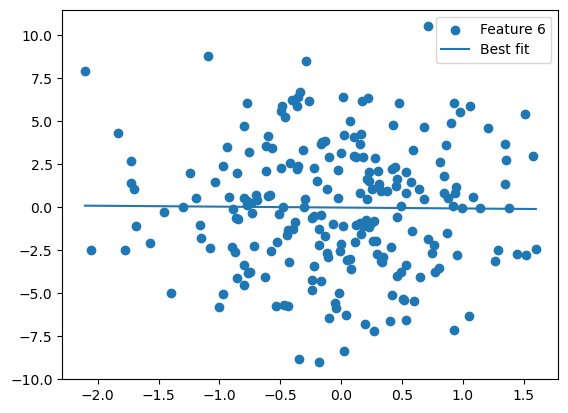

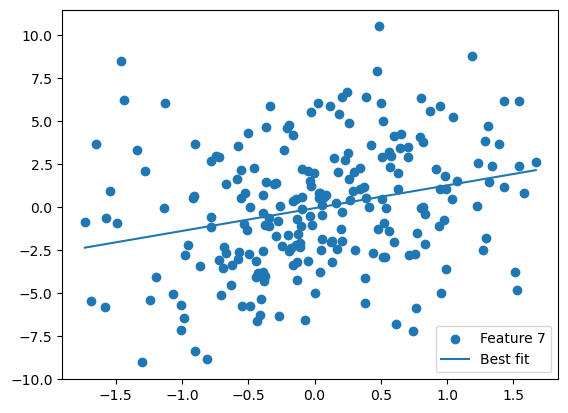

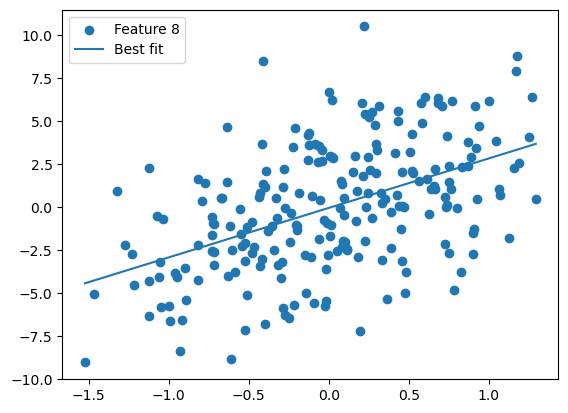

In [23]:
for i in range(X_train_clean.shape[1]):
    x = X_train_clean[:, i]
    plt.figure()
    plt.scatter(x, y_train_clean, label=f'Feature {i+1}')
    plt.plot(np.sort(x), np.polyval(np.polyfit(x, y_train_clean, 1), np.sort(x)), label='Best fit')
    plt.legend()
    plt.show()

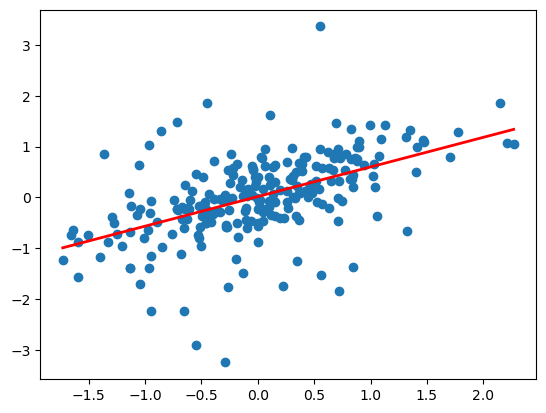

Variance from line (x4): 11.414687379875089
Variance from line (x5): 12.902372237205531


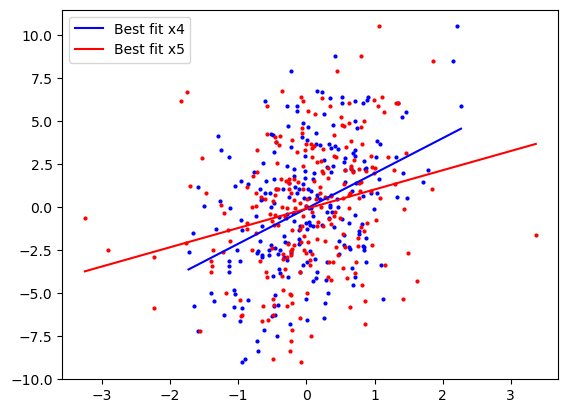

In [24]:
import numpy as np
import matplotlib.pyplot as plt

x1 = std_X_train[:, 3]
x2 = std_X_train[:, 4]

plt.figure()
plt.scatter(x1, x2)
m, b = np.polyfit(x1, x2, 1)
x_fit = np.array([np.min(x1), np.max(x1)])
y_fit = m * x_fit + b
plt.plot(x_fit, y_fit, color='red', linewidth=2)
plt.show()

coef1 = np.polyfit(x1, y_train, 1)
coef2 = np.polyfit(x2, y_train, 1)

yhat1 = np.polyval(coef1, x1)
yhat2 = np.polyval(coef2, x2)


res1 = y_train - yhat1
res2 = y_train - yhat2

var1 = np.var(res1)
var2 = np.var(res2)


print("Variance from line (x4):", var1)
print("Variance from line (x5):", var2)


plt.figure()
plt.scatter(x1, y_train, s=4, color="blue")
plt.scatter(x2, y_train, s=4, color="red")

plt.plot(
    np.sort(x1),
    np.polyval(coef1, np.sort(x1)),
    color="blue", label="Best fit x4"
)


plt.plot(
    np.sort(x2),
    np.polyval(coef2, np.sort(x2)),
    color="red", label="Best fit x5"
)

plt.legend()
plt.show()

In [25]:
a=std_X_train[:,4]
combo=np.where(np.abs(a)<2,a,std_X_train[:,3])
combo = combo.reshape(-1,1)
std_X_train_f = np.concatenate([std_X_train, combo], axis=1)

a=std_X_test[:,4]
combo=np.where(np.abs(a)<2,a,std_X_test[:,3])
combo = combo.reshape(-1,1)
std_X_test_f = np.concatenate([std_X_test, combo], axis=1)

Variance from line (x7): 12.583523637068817
Variance from line (x8): 10.2825255694888


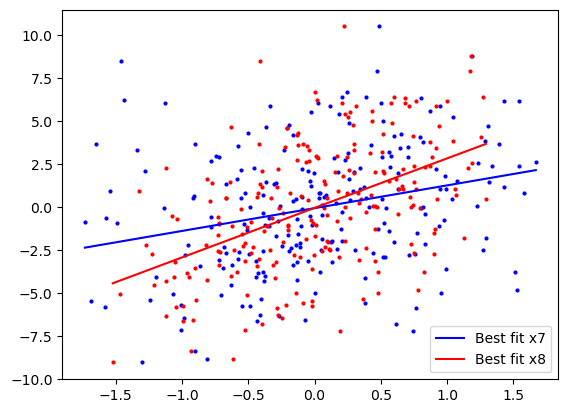

In [26]:
import numpy as np
import matplotlib.pyplot as plt

x1 = X_train_clean[:, 6]
x2 = X_train_clean[:, 7]

coef1 = np.polyfit(x1, y_train_clean, 1)
coef2 = np.polyfit(x2, y_train_clean, 1)

yhat1 = np.polyval(coef1, x1)
yhat2 = np.polyval(coef2, x2)


res1 = y_train_clean - yhat1
res2 = y_train_clean - yhat2

var1 = np.var(res1)
var2 = np.var(res2)


print("Variance from line (x7):", var1)
print("Variance from line (x8):", var2)



plt.figure()
plt.scatter(x1, y_train_clean, s=4, color="blue")
plt.scatter(x2, y_train_clean, s=4, color="red")

plt.plot(
    np.sort(x1),
    np.polyval(coef1, np.sort(x1)),
    color="blue", label="Best fit x7"
)


plt.plot(
    np.sort(x2),
    np.polyval(coef2, np.sort(x2)),
    color="red", label="Best fit x8"
)

plt.legend()
plt.show()

# Tasks

## Task1

Coefficient path fpr ridge and lasso regression, Heatmap, Scatter plots are generated above

## Task 2

### 1. Feature Elimination

Feature x6 is the one that goes to zero immediately

### 2. Correlated Functions

OLS gives features x2 and x3 different weights because it gets confused by highly similar features and in ridge they converge because they are basically telling the model the same thing  
  
correlation coef = 0.76

### 3. Reliability vs. Availability

Sensor A is x4 and sensor B is x5   
  
As seen in the scatter plot above, x4 has high variance and is uniformly distibuted aroumd the line and we can see that x5 is very close to the line(we barely see the line) and the remaining points are less and off from the line indicating that the sensor is off at those times  

The composite feature that we decided was x9 = (|x5| < 2) ? x5 : x4

### 4. Independent Signals

x1(z) does maintain it magnitude in lasso coefficient(upto some extent)

x1 is not correlated to any other feature and from the lasso path it is obvious that there is no redundance in x1 and any other feature  

### 5. Structural Corruption vs. Noise

The remaining features are x8 and x7, x7 shows uniform noise around a linear trend, while x8 contains strong outliers.

When applying LASSO, x8 is penalized to zero first. This shows that LASSO prefers stable features and suppresses those affected by outliers, since squared error is highly sensitive to extreme values


# Final

In [27]:
def train_and_write_csv(feature_indices, output_csv):
    X_train_sel = std_X_train_f[:, feature_indices]
    X_test_sel = std_X_test_f[:, feature_indices]
    model = sklearn.linear_model.Ridge(alpha=0.01)
    model.fit(X_train_sel, y_train)

    y_pred = model.predict(X_test_sel)
    output = y_pred
    np.savetxt(output_csv,output,delimiter=",",header="y",comments="")

    print(f"Saved predictions to {output_csv}")
    return model

model=train_and_write_csv([0, 1, 6, 8],"24b1006_24b1009.csv") 

Saved predictions to 24b1006_24b1009.csv


In [28]:
from sklearn import model_selection
cvScores = model_selection.cross_val_score(model, std_X_train_f, y_train, cv=5, scoring='neg_mean_squared_error')
rmseScores= np.sqrt(-cvScores)
print(f"Cross-Validation: {rmseScores.mean():.2f}")

Cross-Validation: 2.09
